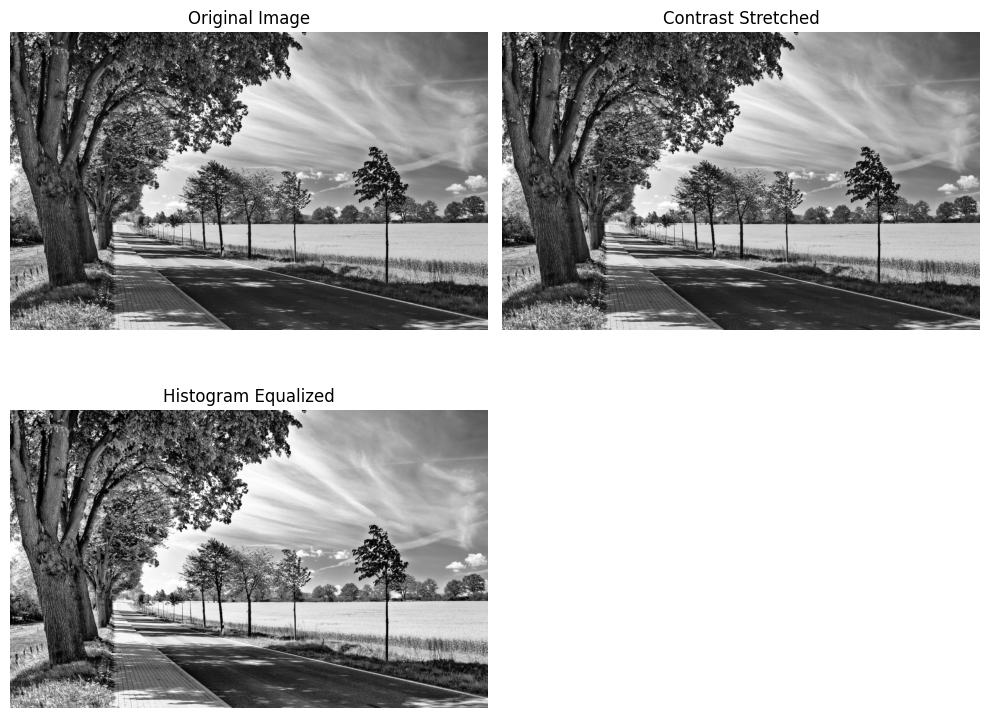

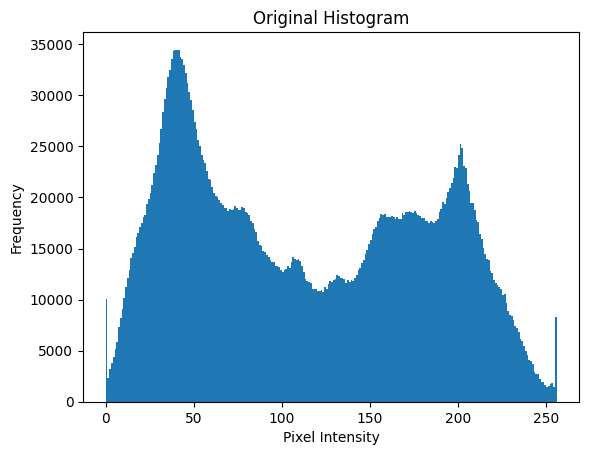

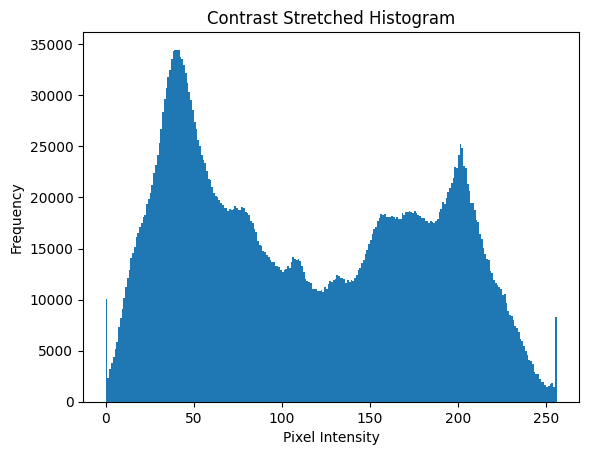

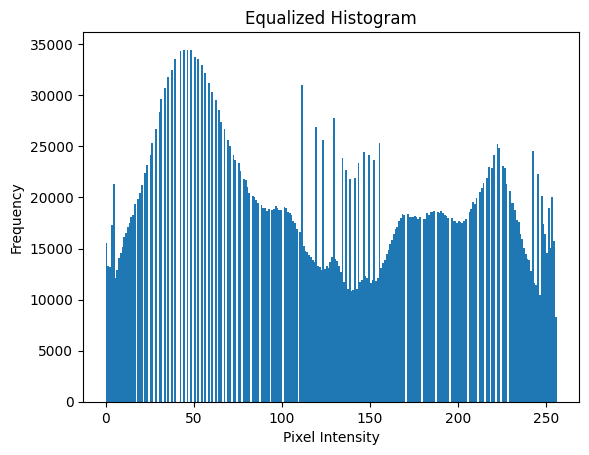

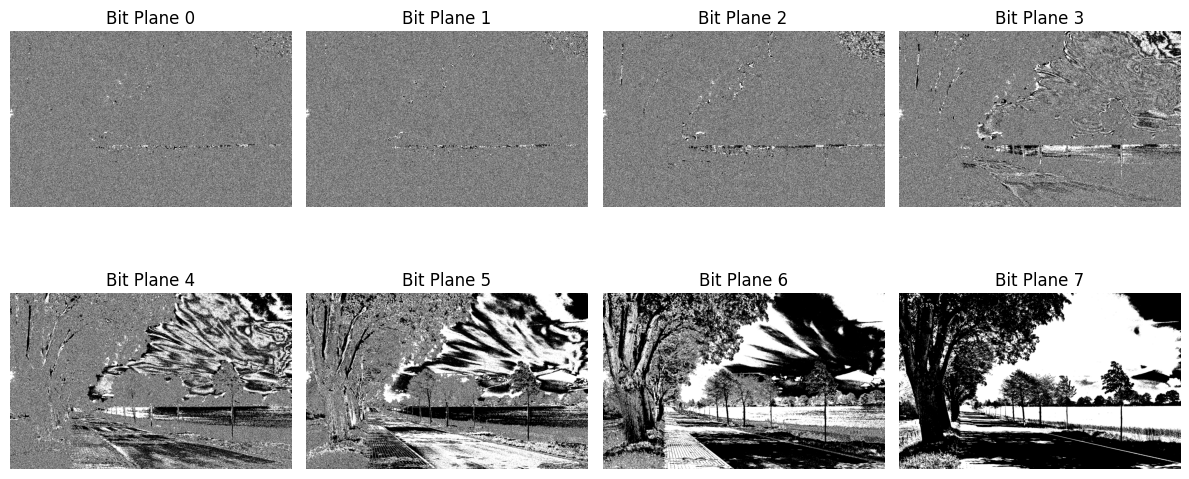

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('/content/image.jpg', cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found!")
    exit()

def contrast_stretch(img):
    min_val = np.min(img)
    max_val = np.max(img)

    stretched = ((img - min_val) / (max_val - min_val)) * 255
    return stretched.astype(np.uint8)

stretched_img = contrast_stretch(image)

def plot_histogram(img, title):
    plt.figure()
    plt.hist(img.ravel(), bins=256, range=[0,256])
    plt.title(title)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.show()

equalized_img = cv2.equalizeHist(image)

def bit_plane_slicing(img):
    bit_planes = []

    for i in range(8):
        bit_plane = (img >> i) & 1
        bit_planes.append(bit_plane * 255)

    return bit_planes

bit_planes = bit_plane_slicing(image)

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(stretched_img, cmap='gray')
plt.title("Contrast Stretched")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(equalized_img, cmap='gray')
plt.title("Histogram Equalized")
plt.axis('off')

plt.tight_layout()
plt.show()

plot_histogram(image, "Original Histogram")
plot_histogram(stretched_img, "Contrast Stretched Histogram")
plot_histogram(equalized_img, "Equalized Histogram")

plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(bit_planes[i], cmap='gray')
    plt.title(f'Bit Plane {i}')
    plt.axis('off')

plt.tight_layout()
plt.show()